In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
import os

In [14]:
from langchain_groq import ChatGroq

In [15]:
load_dotenv()

True

In [16]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [17]:
# create state
class LLMState(TypedDict):
    question: str
    answer: str

In [18]:
# function to process user query
def llm_qa(state: LLMState) -> LLMState:

    question = state["question"]
    
    prompt = f"Answer the following question: {question}"

    response = model.invoke(prompt).content

    state["answer"] = response

    return state

In [19]:
# create Graph
graph = StateGraph(LLMState)

# create Nodes
graph.add_node("llm_qa",llm_qa)

# create edges
graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)


# compile graph
workflow = graph.compile()

In [20]:
# execute workflow

question = "What is the capital of India?"

initial_state = {"question": question}

final_state = workflow.invoke(initial_state)


In [21]:
print(final_state)

{'question': 'What is the capital of India?', 'answer': 'The capital of India is New Delhi.'}


In [22]:
print(final_state["answer"])

The capital of India is New Delhi.


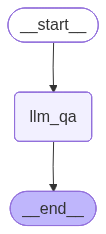

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [24]:
model.invoke("distance of moon from earth ?").content

"The average distance from the Earth to the Moon is approximately **384,400 kilometers (238,900 miles)**. This distance is constantly changing due to the elliptical shape of the Moon's orbit around our planet.\n\nAt its closest point, called **perigee**, the Moon is about **356,400 kilometers (221,500 miles)** away from Earth. At its farthest point, called **apogee**, the distance is around **405,500 kilometers (252,000 miles)**.\n\nIt's worth noting that the Moon's orbit is not a perfect circle, which is why we see variations in the distance between the Earth and the Moon over the course of a month."